In [ ]:
#Import the Python libraries needed for data handling, visualization, and modeling.
import pandas as pd
import numpy as np
import re
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from bs4 import BeautifulSoup

In [ ]:
#Download the Kaggle dataset and save the local directory path
import kagglehub

path = kagglehub.dataset_download("jessicali9530/kuc-hackathon-winter-2018")

print("Path to dataset files:", path)

100%|██████████| 40.7M/40.7M [00:01<00:00, 22.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/kuc-hackathon-winter-2018/versions/2


In [ ]:
import os

# List the contents of the directory
print(os.listdir(path))

['drugsComTest_raw.csv', 'drugsComTrain_raw.csv']


In [ ]:
#Load a CSV file into a pandas DataFrame.
data = pd.read_csv(os.path.join(path, 'drugsComTrain_raw.csv'))

In [ ]:
#Display data in the notebook output (usually to preview a DataFrame or variable contents)
data

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79


In [ ]:
#Compute summary statistics for the dataset’s numeric columns.
data.describe()

,uniqueID,rating,usefulCount
count,161297.000000,161297.000000,161297.000000
mean,115923.585305,6.994377,28.004755
std,67004.445170,3.272329,36.403742
min,2.000000,1.000000,0.000000
25%,58063.000000,5.000000,6.000000
50%,115744.000000,8.000000,16.000000
75%,173776.000000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [ ]:
#Review column data types and non-null counts to assess data quality.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


In [ ]:
#Check the number of rows and columns in the DataFrame
data.shape

(161297, 7)

In [ ]:
#Inspect column names to understand the dataset schema.
data.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')

In [ ]:
#Inspect the DataFrame index to understand row identifiers/ordering.
data.index

RangeIndex(start=0, stop=161297, step=1)

In [ ]:
#Temporarily change pandas display settings to show more columns/text when previewing the data.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
data.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.) I called his doctor on Monday morning and she said to stick it out a few days. See how he did at school, and with getting up in the morning. The last two days have been problem free. He is MUCH more agreeable than ever. He is less emotional (a good thing), less cranky. He is remembering all the things he should. Overall his behavior is better. \r\nWe have tried many different medications and so far this is the most effective.""",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not available in US, so I switched to Lybrel, because the ingredients are similar. When my other pills ended, I started Lybrel immediately, on my first day of period, as the instructions said. And the period lasted for two weeks. When taking the second pack- same two weeks. And now, with third pack things got even worse- my third period lasted for two weeks and now it&#039;s the end of the third week- I still have daily brown discharge.\r\nThe positive side is that I didn&#039;t have any other side effects. The idea of being period free was so tempting... Alas.""",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth control. I&#039;m glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is that it made my periods longer (5-6 days to be exact) I used to only have periods for 3-4 days max also made my cramps intense for the first two days of my period, I never had cramps before using birth control. Other than that in happy with the patch""",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around. I feel healthier, I&#039;m excelling at my job and I always have money in my pocket and my savings account. I had none of those before Suboxone and spent years abusing oxycontin. My paycheck was already spent by the time I got it and I started resorting to scheming and stealing to fund my addiction. All that is history. If you&#039;re ready to stop, there&#039;s a good chance that suboxone will put you on the path of great life again. I have found the side-effects to be minimal compared to oxycontin. I&#039;m actually sleeping better. Slight constipation is about it for me. It truly is amazing. The cost pales in comparison to what I spent on oxycontin.""",9,27-Nov-16,37


In [ ]:
data.tail(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 2014. I have not had any alcohol at all since that post, have reduced my dosage to 1 pill first thing in the morning. I am a very social person, and entertained a great deal. I was very very worried that I would relapse if faced with the availability of alcohol. I have sailed through all my seasonal parties, early spring get togethers and weekly &quot;wings and beer&quot; with friends with not one slip. My husband and daughter are huge supporters. As I write this, I have various wines and liquors in my cabinet - serve to guests - and have no interest at all in consuming booze in any form. Again, I state that Campral saved my life.""",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immediately became anxious and could not sit still . The PA said &quot;oh yes this happens sometimes&quot;. They had to give me Benadryl to calm me down. It was the worst experience I have had -out of control and jumpy. """,1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed bad rash and MD refused to continue medication.""",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years, I spent my first 38 on Synthroid and various t4 formulas, I could not stand the up and down of Synthroid, it never was steady. Every time I went to the Dr. It was adjusted, it could not regulate me and most Dr&#039;s. Just played with raising and lowering the mg levels. \r\nFinally a person I new told me I should see her Dr. I did, and that was the beginning of a beautiful relationship with Armour Thyroid. I&#039;ve never felt better, my bad symptoms went away, and I feel almost human. It holds me steady for longer periods. sometimes the patient knows best, regardless of what the blood tests say. Armour contains unknown ingredients that can&#039;t be isolated into a synthetic pill form, Armour is natural, and best.""",10,19-Sep-15,79
161296,215220,Lubiprostone,"Constipation, Chronic","""I&#039;ve had chronic constipation all my adult life. Tried Linzess, it worked for a month then stopped. Doctor started me on Amitiza (24 mg) and it is a miracle. I&#039;ve been on for four months now. After a life of 7-10 days between bowel motions, I now go comfortably 3-4 times per week. No pain, very little gas. It&#039;s a miracle for me.""",9,13-Dec-14,116


In [ ]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')
data.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [ ]:
#Convert the date column from strings into proper datetime values.
data["date"] = pd.to_datetime(data["date"], format="%d-%b-%y")


In [ ]:
#Format datetime values into a standardized YYYY-MM-DD string format.
data["date"] = data["date"].dt.strftime("%Y-%m-%d")


**Exploratory Data Analysis**


Visualize the distribution of review ratings to understand class balance in the dataset.
This helps determine whether the sentiment models may become biased toward positive or negative predictions due to imbalanced data.

/tmp/ipython-input-2908106856.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(data1['review'].resample('M').count())


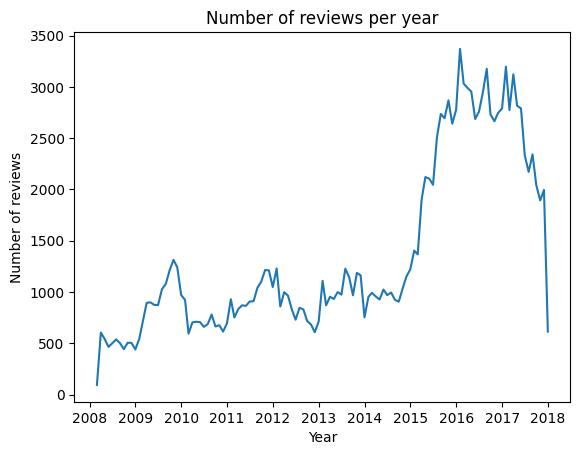

In [ ]:
data['date'] = pd.to_datetime(data['date'])
data1 = data
data1 = data1.set_index('date')
plt.plot(data1['review'].resample('M').count())
plt.xlabel('Year')
plt.ylabel('Number of reviews')
plt.title('Number of reviews per year')
plt.show()

Examine how review ratings vary over time using the date field.
This checks for temporal trends that could influence sentiment patterns, such as shifts in user satisfaction across years.

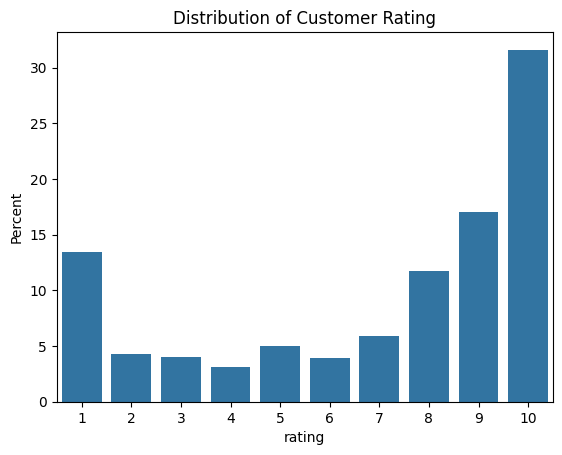

In [ ]:
ax = sns.barplot(data=data, x='rating', y='rating', estimator=lambda x: len(x) / len(data) * 100)
ax.set(ylabel="Percent")
plt.title('Distribution of Customer Rating')
plt.show()

Analyze the relationship between review ratings and review text length.
This explores whether longer reviews tend to be more positive or negative, which can affect how sentiment models interpret intensity.

/tmp/ipython-input-2633845017.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(data1['rating'].resample('M').mean())


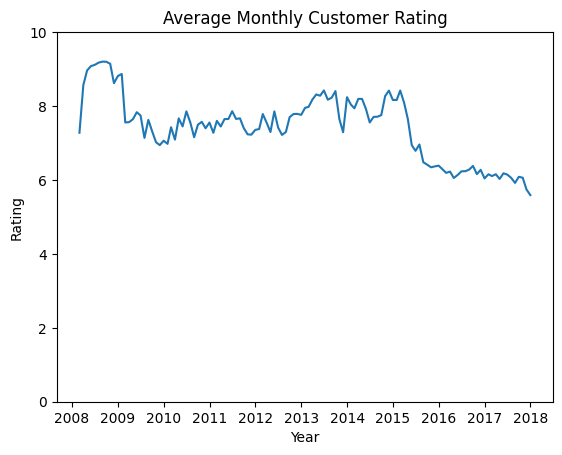

In [ ]:
plt.plot(data1['rating'].resample('M').mean())
plt.xlabel('Year')
plt.ylabel('Rating')
plt.title('Average Monthly Customer Rating')
plt.ylim(0,10)
plt.show()

**Data Cleaning**

In [ ]:
import html
import re

In [ ]:
#Define clean_review() as a reusable helper for the workflow (so later cells can call it consistently).
def clean_review(t):
    t = "" if pd.isna(t) else str(t)
    t = html.unescape(t)
    t = re.sub(r"<br\s*/?>", " ", t)
    t = re.sub(r"[^A-Za-z\s']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    if t == "":
        return "emptyreview"   # placeholder so VADER can score
    return t.lower()

data["text"] = data["review"].apply(clean_review)

In [ ]:
#Define clean_text() as a reusable helper for the workflow (so later cells can call it consistently).
def clean_text(text):
    return BeautifulSoup(text, "html.parser").get_text()

data['text'] = data['review'].apply(clean_text)

In [ ]:
data['text'][0]

'"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"'

In [ ]:
data['text'][5]

'"2nd day on 5mg started to work with rock hard erections however experianced headache, lower bowel preassure. 3rd day erections would wake me up & hurt! Leg/ankles aches   severe lower bowel preassure like you need to go #2 but can\'t! Enjoyed the initial rockhard erections but not at these side effects or $230 for months supply! I\'m 50 & work out 3Xs a week. Not worth side effects!"'

**STOP WORDS**

**STEP 5: Apply Pretrained Models**


In [ ]:
# VADER

import nltk
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon') #import nltk

sid = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# df must have df["review"]
data["text"] = data["review"].fillna("").astype(str)


In [ ]:
# Compute the VADER sentiment score for each text entry
# polarity_scores() returns a dictionary with neg, neu, pos, and compound
# We extract only the "compound" score because it is the normalized overall sentiment (-1 to 1)
data["vader_compound"] = data["text"].apply(lambda t: sid.polarity_scores(t)["compound"])
data[["text", "vader_compound"]].head(5)


,text,vader_compound
0,"""It has no side effect, I take it in combinati...",-0.2960
1,"""My son is halfway through his fourth week of ...",0.8603
2,"""I used to take another oral contraceptive, wh...",0.7962
3,"""This is my first time using any form of birth...",0.7184
4,"""Suboxone has completely turned my life around...",0.9403


In [ ]:
# Function to convert the continuous VADER compound score into categorical sentiment labels
# Default VADER thresholds:
#   >= 0.05  → Positive
#   <= -0.05 → Negative
#   Otherwise → Neutral
def vader_label(c, pos_thr=0.05, neg_thr=-0.05):
    if c >= pos_thr:
        return "pos"
    elif c <= neg_thr:
        return "neg"
    else:
        return "neu"
# Apply the labeling function to every compound score
# This transforms numeric sentiment into a classification task
data["vader_label"] = data["vader_compound"].apply(vader_label)

# Count how many texts fall into each sentiment category
data["vader_label"].value_counts()


,count
vader_label,
neg,80587
pos,73129
neu,7581


In [ ]:
data.sort_values("vader_compound", ascending=False)[["review", "vader_compound", "vader_label"]].head(5)


,review,vader_compound,vader_label
8970,"""This is much much better and get a much bette...",0.9952,pos
75151,"""I have been using Elmiron since February 2008...",0.9952,pos
35553,"""This is much much better and get a much bette...",0.9952,pos
141674,"""I started birth control at age 17 (orto tri c...",0.9951,pos
74225,"""I&#039;ve been taking Taytulla for 4 months n...",0.9943,pos


In [ ]:
# Filter the dataset to only include extreme opinions
# rating == 10 → strongest positive sentiment
# rating == 1  → strongest negative sentiment
# want to look at what is negative and what is positive
data_best_worst = data[(data["rating"]==10) | (data["rating"]==1)].reset_index()

In [ ]:
print(data_best_worst.loc[0, 'text'])
print()
sid.polarity_scores(data_best_worst.loc[0, 'text'])

"He pulled out, but he cummed a bit in me. I took the Plan B 26 hours later, and took a pregnancy test two weeks later - - I&#039;m pregnant."



{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [ ]:
print(data_best_worst.loc[10, 'text'])
print()
sid.polarity_scores(data_best_worst.loc[10, 'text'])

"Hi all, My son who is 12 was diagnosed when he was in 2nd grade. We tried everything before medication. When we tried meds, the first one made him loose weight, fast. The second gave him a nasty tic that thankfully went away as soon as he stopped the med, the third worked for a couple of years and around January of last year we started to have problems so his doctor recommended Daytrana. It has been wonderful for my son! Easy to use, he handles this for himself each day and takes it off when he gets home from school. The patch effects last long enough for him to do his homework. He does have issues with weight gain and sleep but he uses melatonin before bed if he feels like he will not be able to shut down. The shortage is KILLING us!"



{'neg': 0.108, 'neu': 0.81, 'pos': 0.082, 'compound': -0.747}

In [ ]:
print(data_best_worst.loc[55, 'text'])
print()
sid.polarity_scores(data_best_worst.loc[55, 'text'])

"Accurate information."



{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

**Visualize sentiments**

In [ ]:
# Function to visualize sentiment scores as a heatmap
sns.set(rc={'figure.figsize':(30,1)})

def visualise_sentiments(data):
  sns.heatmap(pd.DataFrame(data).set_index("Sentence").T,center=0, annot=True, cmap = "PiYG")

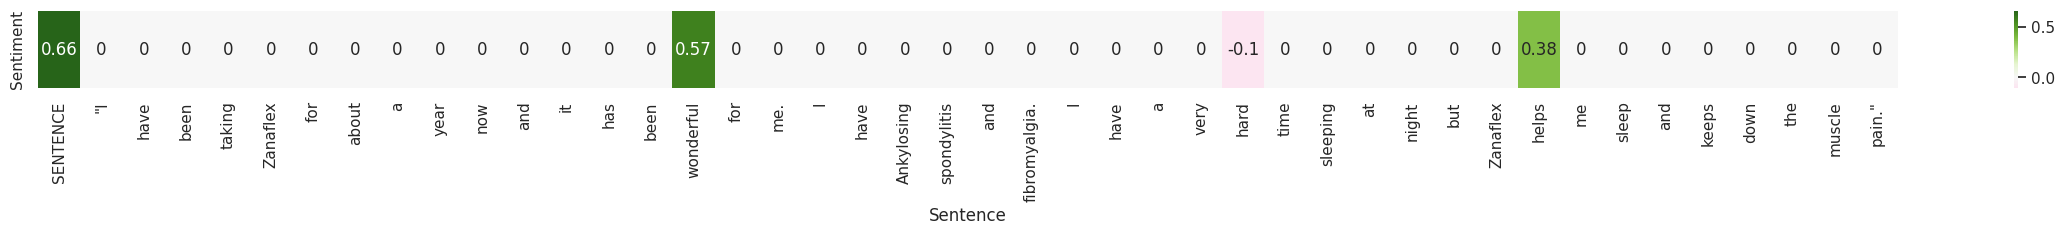

In [ ]:
# Visualize sentiment at both the sentence level and word level
visualise_sentiments({
    "Sentence":["SENTENCE"] + data_best_worst.loc[68, 'text'].split(),
    "Sentiment":[sid.polarity_scores(data_best_worst.loc[68, 'text'])["compound"]]
    + [sid.polarity_scores(word)["compound"] for word in data_best_worst.loc[68, 'text'].split()]
})
    # First value = compound sentiment of the entire review
    # Remaining values = compound sentiment for each individual word
    # This helps show which words contribute most to the overall polarity

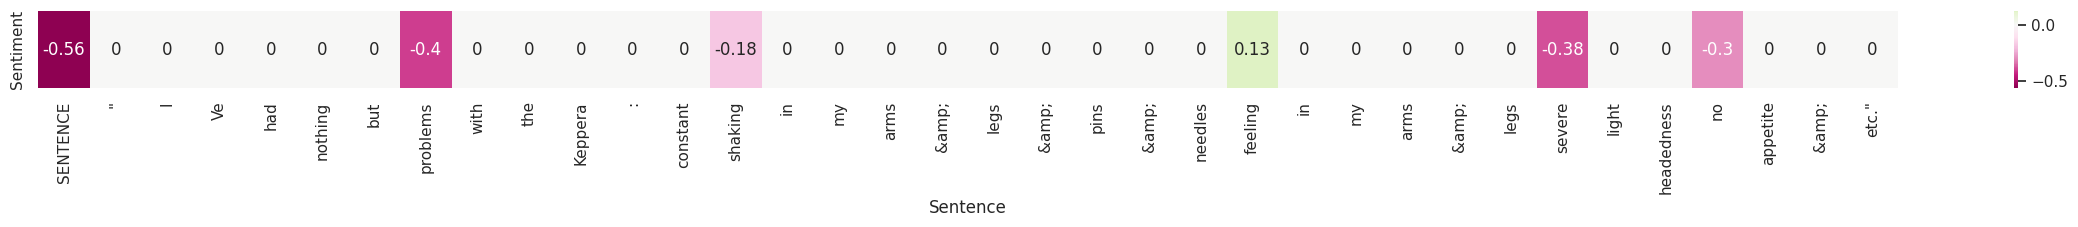

In [ ]:
visualise_sentiments({
    "Sentence":["SENTENCE"] + data_best_worst.loc[2, 'text'].split(),
    "Sentiment":[sid.polarity_scores(data_best_worst.loc[2, 'text'])["compound"]]
    + [sid.polarity_scores(word)["compound"] for word in data_best_worst.loc[2, 'text'].split()]
})

**TEXTBLOB**

In [ ]:
from textblob import TextBlob


In [ ]:
# Compute sentiment polarity using TextBlob
# polarity ranges from -1 (negative) to +1 (positive), similar to VADER compound
data["tb_polarity"] = data["text"].apply(lambda t: TextBlob(t).sentiment.polarity)

data[["text","tb_polarity"]].head(5)


,text,tb_polarity
0,"""It has no side effect, I take it in combinati...",0.000000
1,"""My son is halfway through his fourth week of ...",0.168333
2,"""I used to take another oral contraceptive, wh...",0.067210
3,"""This is my first time using any form of birth...",0.179545
4,"""Suboxone has completely turned my life around...",0.194444


In [ ]:
# Convert TextBlob polarity scores into categorical sentiment labels
# Uses the same thresholds as VADER so results are comparable across models
def tb_label(p, pos_thr=0.05, neg_thr=-0.05):
    if p >= pos_thr:
        return "pos"
    elif p <= neg_thr:
        return "neg"
    else:
        return "neu"

# Apply the labeling function to each polarity score
# This turns regression-style output (-1 to 1) into classification labels
data["tb_label"] = data["tb_polarity"].apply(tb_label)

data["tb_label"].value_counts()


,count
tb_label,
pos,83820
neu,38924
neg,38553


In [ ]:
# This allows access to linguistic features such as sentiment, noun phrases, and tokenization
blob = TextBlob(data_best_worst.loc[0,"text"])
print(blob)
print()
print(blob.sentiment)

"He pulled out, but he cummed a bit in me. I took the Plan B 26 hours later, and took a pregnancy test two weeks later - - I&#039;m pregnant."

Sentiment(polarity=0.1111111111111111, subjectivity=0.16666666666666666)


In [ ]:
blob = TextBlob(data_best_worst.loc[12,"text"])
print(blob)
print()
print(blob.sentiment)

"I am 30 years old. I had a multiple composite spinal injuries 15 years ago. The aches and pains unbearable. I started taking anti-inflammatories about 2 years ago. I started getting injections every month of Toradol and &quot;Depo&quot; something. I am almost off all pain meds I mean I still have bad days but I can function again."

Sentiment(polarity=-0.22812499999999997, subjectivity=0.3885416666666667)


In [ ]:
# define a function that accepts text and returns the polarity
def detect_sentiment(text):

    #Converts the text into textblob object and then retuns
    #the subjectivity.
    blob = TextBlob(text)

    # return the subjectivity
    return blob.sentiment.subjectivity

In [ ]:
blob = TextBlob(data_best_worst.loc[12,"text"])
print(blob)
print()
print(blob.sentiment)

"I am 30 years old. I had a multiple composite spinal injuries 15 years ago. The aches and pains unbearable. I started taking anti-inflammatories about 2 years ago. I started getting injections every month of Toradol and &quot;Depo&quot; something. I am almost off all pain meds I mean I still have bad days but I can function again."

Sentiment(polarity=-0.22812499999999997, subjectivity=0.3885416666666667)


In [ ]:
# Calculate TextBlob subjectivity score for each extreme review
# subjectivity ranges from 0 → objective/factual
#                         to 1 → opinionated/personal
# This helps analyze whether strong ratings are driven by emotion vs factual statements
data_best_worst["tb_subjectivity"] = data_best_worst["text"].apply(
    lambda t: TextBlob(t).sentiment.subjectivity
)

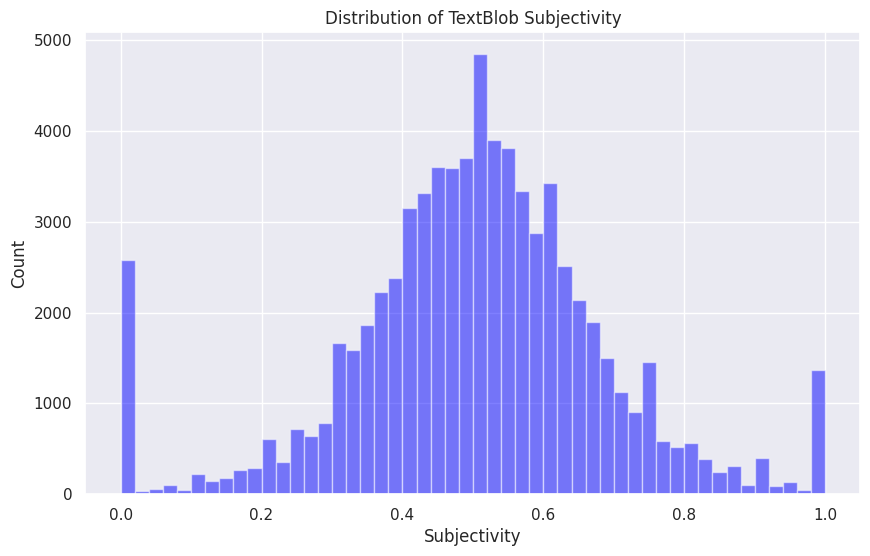

In [ ]:
import matplotlib.pyplot as plt

# Create a histogram to visualize how subjective the extreme reviews are

plt.figure(figsize=(10,6))
plt.hist(data_best_worst["tb_subjectivity"], bins=50, color="blue", alpha=0.5)

plt.xlabel("Subjectivity")
plt.ylabel("Count")
plt.title("Distribution of TextBlob Subjectivity")
plt.show()


**Compare VADER & TEXTBLOB**

In [ ]:
data[["vader_label","tb_label"]].value_counts()


vader_label  tb_label
pos          pos         53146
neg          neg         30960
             pos         27331
             neu         22296
pos          neu         13636
             neg          6347
neu          pos          3343
             neu          2992
             neg          1246
Name: count, dtype: int64

In [ ]:
# Identify reviews where the two models predict different sentiments
# This isolates difficult or ambiguous cases useful for error analysis
disagree = data[data["vader_label"] != data["tb_label"]]

disagree[["review","vader_label","tb_label"]].head(10)


,review,vader_label,tb_label
0,"""It has no side effect, I take it in combinati...",neg,neu
5,"""2nd day on 5mg started to work with rock hard...",neg,neu
6,"""He pulled out, but he cummed a bit in me. I t...",neu,pos
7,"""Abilify changed my life. There is hope. I was...",neg,pos
8,""" I Ve had nothing but problems with the Kepp...",neg,pos
9,"""I had been on the pill for many years. When m...",neg,pos
11,"""I have taken anti-depressants for years, with...",neu,pos
13,"""Have a little bit of a lingering cough from a...",neg,neu
14,"""Started Nexplanon 2 months ago because I have...",neg,neu
16,"""This drug worked very well for me and cleared...",neg,neu


In [ ]:
# Compare how often VADER and TextBlob agree or disagree on sentiment classification
pair_counts = (
    data.groupby(["vader_label", "tb_label"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

pair_counts.head(15)


,vader_label,tb_label,count
8,pos,pos,53146
0,neg,neg,30960
2,neg,pos,27331
1,neg,neu,22296
7,pos,neu,13636
6,pos,neg,6347
5,neu,pos,3343
4,neu,neu,2992
3,neu,neg,1246


In [ ]:
# Create a confusion-style table comparing VADER vs TextBlob predictions
# Rows  → VADER predicted labels
# Columns → TextBlob predicted labels
# Each cell shows how many reviews fall into that combination
pd.crosstab(data["vader_label"], data["tb_label"])


tb_label,neg,neu,pos
vader_label,,,
neg,30960,22296,27331
neu,1246,2992,3343
pos,6347,13636,53146


In [ ]:
# Normalized comparison table between VADER and TextBlob
# normalize="index" converts each row into percentages
# → Shows: given VADER predicted X, how often does TextBlob predict each class?
pd.crosstab(data["vader_label"], data["tb_label"], normalize="index").round(3)


tb_label,neg,neu,pos
vader_label,,,
neg,0.384,0.277,0.339
neu,0.164,0.395,0.441
pos,0.087,0.186,0.727


In [ ]:
# Another way to summarize agreement between VADER and TextBlob
# Produces a ranked table of all label pair combinations
(data.groupby(["vader_label","tb_label"])
     .size()
     .reset_index(name="count")
     .sort_values("count", ascending=False))


,vader_label,tb_label,count
8,pos,pos,53146
0,neg,neg,30960
2,neg,pos,27331
1,neg,neu,22296
7,pos,neu,13636
6,pos,neg,6347
5,neu,pos,3343
4,neu,neu,2992
3,neu,neg,1246


**TRANSFORMER TORCH**

In [ ]:
!pip -q install transformers torch


In [ ]:
# Import PyTorch (backend used by many HuggingFace models for tensor computation)
# Import the HuggingFace pipeline helper
import torch
from transformers import pipeline


In [ ]:
# Load a pretrained transformer emotion classifier
# Uses DistilRoBERTa fine-tuned to detect emotions (joy, anger, sadness, etc.)
# device = 0 → GPU if available, otherwise CPU (-1)
emo_clf = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    device=0 if torch.cuda.is_available() else -1
)

# Convert text column into a clean list of strings
# fillna prevents model errors caused by missing values
texts = data["text"].fillna("").astype(str).tolist()

# Store predictions
hf_emotion = []
hf_emotion_score = []

# Run inference in batches to avoid memory issues and improve speed
batch_size = 32
for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    # truncation=True ensures long reviews are cut to model token limit
    preds = emo_clf(batch, truncation=True)

    # Save predicted label and confidence score
    hf_emotion.extend([p["label"] for p in preds])
    hf_emotion_score.extend([p["score"] for p in preds])

# Attach predictions back to dataset
data["hf_emotion"] = hf_emotion
data["hf_emotion_score"] = hf_emotion_score


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Convert multi-class emotion predictions into binary sentiment
# Positive emotions → "pos"
# All other emotions → "neg"
# This allows comparison with VADER and TextBlob (which are binary/ternary sentiment models)
def emotion_to_binary(e):
    e = str(e).lower().strip()
    if e in ["joy", "surprise"]:
        return "pos"
    else:
        return "neg"

# Apply conversion to transformer emotion predictions
data["hf_label"] = data["hf_emotion"].apply(emotion_to_binary)



In [ ]:
# Check distribution of transformer-based sentiment labels
# dropna=False ensures missing values (if any) are also counted
print(data["hf_label"].value_counts(dropna=False))

# Verify whether any predictions failed and produced NaN labels
# Useful data quality check before evaluation
print("Any NaNs in hf_label?", data["hf_label"].isna().sum())


hf_label
neg    132955
pos     28342
Name: count, dtype: int64
Any NaNs in hf_label? 0


#Step 6: Analyze and Review Results


In [ ]:
# Create a clean evaluation dataset containing only relevant fields
# Keeps the original review plus predictions from all three models
final_df = data[[
    "drugName",
    "text",

    "vader_label",
    "vader_compound",

    "tb_label",
    "tb_polarity",

    "hf_label",
    "hf_emotion",
    "hf_emotion_score",

]].copy()


In [ ]:
# Compare VADER vs TextBlob predictions using the cleaned evaluation dataset
# Helps evaluate agreement after model outputs were consolidated
pd.crosstab(final_df["vader_label"], final_df["tb_label"])

tb_label,neg,neu,pos
vader_label,,,
neg,30960,22296,27331
neu,1246,2992,3343
pos,6347,13636,53146


In [ ]:
# Compare VADER sentiment predictions with the transformer-based binary sentiment
# Shows how often the rule-based model and the deep learning model agree or disagree
pd.crosstab(final_df["vader_label"], final_df["hf_label"])


hf_label,neg,pos
vader_label,,
neg,74048,6539
neu,6437,1144
pos,52470,20659


In [ ]:
# Compare TextBlob sentiment predictions with the transformer-based binary sentiment
# Useful for identifying whether the lexicon-based model aligns with the deep learning model
pd.crosstab(final_df["tb_label"], final_df["hf_label"])


hf_label,neg,pos
tb_label,,
neg,36297,2256
neu,34456,4468
pos,62202,21618


In [ ]:
# Summary statistics of VADER compound scores within each predicted label
# Helps verify that numeric sentiment scores align with their assigned categories
# (e.g., positive labels should have higher average compound values)
final_df.groupby("vader_label")["vader_compound"].describe()


,count,mean,std,min,25%,50%,75%,max
vader_label,,,,,,,,
neg,80587.0,-0.659239,0.264458,-0.9984,-0.8920,-0.7269,-0.4588,-0.0500
neu,7581.0,0.000046,0.016913,-0.0498,0.0000,0.0000,0.0000,0.0498
pos,73129.0,0.633742,0.260841,0.0500,0.4346,0.6884,0.8633,0.9952


In [ ]:
# Examine confidence levels of the transformer model by predicted sentiment
# Shows how strongly the model believes its positive vs negative classifications
final_df.groupby("hf_label")["hf_emotion_score"].describe()


,count,mean,std,min,25%,50%,75%,max
hf_label,,,,,,,,
neg,132955.0,0.656421,0.215129,0.175829,0.469883,0.645317,0.856459,0.995585
pos,28342.0,0.665591,0.216299,0.201477,0.475967,0.666377,0.873480,0.993892


In [ ]:
# Summary statistics of TextBlob polarity scores for each predicted sentiment class
# Useful to confirm that negative labels have lower polarity values and positive labels have higher ones

final_df.groupby("tb_label")["tb_polarity"].describe()


,count,mean,std,min,25%,50%,75%,max
tb_label,,,,,,,,
neg,38553.0,-0.196601,0.163540,-1.00,-0.241667,-0.145833,-0.090179,-0.05
neu,38924.0,0.002101,0.026042,-0.05,-0.016667,0.000000,0.022857,0.05
pos,83820.0,0.214237,0.164347,0.05,0.104167,0.167143,0.261111,1.00


In [ ]:
final_df.head(5)

,drugName,text,vader_label,vader_compound,tb_label,tb_polarity,hf_label,hf_emotion,hf_emotion_score
0,Valsartan,"""It has no side effect, I take it in combinati...",neg,-0.2960,neu,0.000000,neg,neutral,0.952218
1,Guanfacine,"""My son is halfway through his fourth week of ...",pos,0.8603,pos,0.168333,neg,anger,0.475341
2,Lybrel,"""I used to take another oral contraceptive, wh...",pos,0.7962,pos,0.067210,neg,sadness,0.277860
3,Ortho Evra,"""This is my first time using any form of birth...",pos,0.7184,pos,0.179545,pos,joy,0.916329
4,Buprenorphine / naloxone,"""Suboxone has completely turned my life around...",pos,0.9403,pos,0.194444,pos,joy,0.720825


In [ ]:
tmp = final_df.copy()

# Measure disagreement between model confidence scores
# Absolute difference shows how far apart the models are numerically
# VADER vs TextBlob
tmp["vader_tb_gap"] = (tmp["vader_compound"] - tmp["tb_polarity"]).abs()

# VADER vs Transformer
# Note: hf_emotion_score is probability confidence, not sentiment polarity,
# so large gaps may reflect scale differences rather than true disagreemen
tmp["vader_hf_gap"] = (tmp["vader_compound"] - tmp["hf_emotion_score"]).abs()

# TextBlob vs Transformer
tmp["tb_hf_gap"] = (tmp["tb_polarity"] - tmp["hf_emotion_score"]).abs()

# Summarize disagreement statistics across the dataset
tmp[["vader_tb_gap","vader_hf_gap","tb_hf_gap"]].describe()



,vader_tb_gap,vader_hf_gap,tb_hf_gap
count,161297.000000,161297.000000,161297.000000
mean,0.557521,0.818245,0.601156
std,0.288633,0.593828,0.297754
min,0.000000,0.000010,0.000024
25%,0.332014,0.270848,0.377493
50%,0.589881,0.714194,0.585066
75%,0.779650,1.345350,0.812367
max,1.885200,1.987808,1.994275


In [ ]:
final_df[final_df["vader_label"] != final_df["tb_label"]][
    ["drugName","text","vader_label","vader_compound","tb_label","tb_polarity"]
].head(10)


,drugName,text,vader_label,vader_compound,tb_label,tb_polarity
0,Valsartan,"""It has no side effect, I take it in combinati...",neg,-0.2960,neu,0.000000
5,Cialis,"""2nd day on 5mg started to work with rock hard...",neg,-0.4342,neu,0.003472
6,Levonorgestrel,"""He pulled out, but he cummed a bit in me. I t...",neu,0.0000,pos,0.111111
7,Aripiprazole,"""Abilify changed my life. There is hope. I was...",neg,-0.9468,pos,0.074107
8,Keppra,""" I Ve had nothing but problems with the Kepp...",neg,-0.5593,pos,0.200000
9,Ethinyl estradiol / levonorgestrel,"""I had been on the pill for many years. When m...",neg,-0.9010,pos,0.079167
11,L-methylfolate,"""I have taken anti-depressants for years, with...",neu,0.0147,pos,0.275000
13,Dextromethorphan,"""Have a little bit of a lingering cough from a...",neg,-0.3292,neu,-0.036574
14,Nexplanon,"""Started Nexplanon 2 months ago because I have...",neg,-0.4309,neu,0.021539
16,Trimethoprim,"""This drug worked very well for me and cleared...",neg,-0.7215,neu,0.029091


In [ ]:
final_df[
    (final_df["hf_label"] != final_df["vader_label"]) &
    (final_df["hf_label"] != final_df["tb_label"])
][
    ["drugName","text","hf_emotion","hf_label","hf_emotion_score",
     "vader_label","vader_compound","tb_label","tb_polarity"]
].head(10)


,drugName,text,hf_emotion,hf_label,hf_emotion_score,vader_label,vader_compound,tb_label,tb_polarity
1,Guanfacine,"""My son is halfway through his fourth week of ...",anger,neg,0.475341,pos,0.8603,pos,0.168333
2,Lybrel,"""I used to take another oral contraceptive, wh...",sadness,neg,0.277860,pos,0.7962,pos,0.067210
6,Levonorgestrel,"""He pulled out, but he cummed a bit in me. I t...",disgust,neg,0.302866,neu,0.0000,pos,0.111111
10,Topiramate,"""I have been on this medication almost two wee...",neutral,neg,0.336887,pos,0.2479,pos,0.179545
11,L-methylfolate,"""I have taken anti-depressants for years, with...",neutral,neg,0.429273,neu,0.0147,pos,0.275000
15,Liraglutide,"""I have been taking Saxenda since July 2016. ...",sadness,neg,0.509364,pos,0.5927,pos,0.209259
20,Atripla,"""Spring of 2008 I was hospitalized with pnuemo...",anger,neg,0.896549,pos,0.7243,pos,0.364167
21,Trazodone,"""I have insomnia, it&#039;s horrible. My story...",fear,neg,0.890478,pos,0.7579,pos,0.061503
22,Etonogestrel,"""Nexplanon does its job. I can have worry free...",sadness,neg,0.918875,pos,0.5325,pos,0.193750
23,Etanercept,"""I live in Western Australia and disturbed by ...",sadness,neg,0.513685,pos,0.7425,pos,0.130096


**EXPORT FOR HUMAN LABELS**

In [ ]:
sample100_final = final_df.sample(n=100, random_state=42).copy()

sample100_final.head(10)


,drugName,text,vader_label,vader_compound,tb_label,tb_polarity,hf_label,hf_emotion,hf_emotion_score
4792,Phentermine,"""I started taking Phentermine just a little ov...",pos,0.6300,pos,0.062753,neg,anger,0.810155
142824,Desvenlafaxine,"""I have had depression for years due to situat...",neg,-0.1045,pos,0.068669,neg,sadness,0.580425
97316,Leuprolide,"""I was actually surprised to learn I had stage...",pos,0.5538,pos,0.197266,pos,surprise,0.959929
21700,Zyclara,"""Have used this for one week but began to have...",neg,-0.9559,neg,-0.333333,neg,fear,0.495128
72063,Diphenhydramine,"""Experienced an allergic reaction during dinne...",neg,-0.7906,pos,0.259091,neg,neutral,0.356014
110597,Progesterone,"""I take this medicine in conjunction with appl...",neu,0.0000,neu,0.000000,neg,neutral,0.772571
60368,Ethinyl estradiol / norethindrone,"""I wanted to give my input since most of these...",neg,-0.1893,pos,0.113021,neg,anger,0.457261
67803,Lansoprazole,"""Expensive but really helps with little or no ...",pos,0.3521,neg,-0.162500,neg,neutral,0.803132
155360,Etanercept,"""I have been on Enbrel for 6 months - - after ...",pos,0.8675,pos,0.059954,pos,joy,0.983726
113108,Silenor,"""I couldn&#039;t stay asleep, tried Lunesta an...",pos,0.6889,neu,0.022222,neg,sadness,0.979732


In [ ]:
sample100_final.to_csv("final_df_sample100.csv", index=False)


**Model comparison to human labels**

In [ ]:
final = pd.read_csv("/content/drive/MyDrive/Spring MSBA/Text mining/human_label_sample_100.csv")
final.head(5)

,row_id,drugName,text,vader_label,vader_compound,tb_label,tb_polarity,hf_label,hf_score,vader_tb_agree,vader_hf_agree,tb_hf_agree,human_label
0,4792,Phentermine,i started taking phentermine just a little ove...,pos,0.6300,pos,0.062753,pos,0.935579,True,True,True,pos
1,142824,Desvenlafaxine,i have had depression for years due to situati...,neg,-0.1045,pos,0.068669,neg,0.990062,False,True,False,pos
2,97316,Leuprolide,i was actually surprised to learn i had stage ...,pos,0.5538,pos,0.197266,pos,0.909624,True,True,True,pos
3,21700,Zyclara,have used this for one week but began to have ...,neg,-0.9559,neg,-0.333333,neg,0.998381,True,True,True,neu
4,72063,Diphenhydramine,experienced an allergic reaction during dinner...,neg,-0.7906,pos,0.259091,neg,0.999426,False,True,False,neu


In [ ]:
final.columns

Index(['row_id', 'drugName', 'text', 'vader_label', 'vader_compound',
       'tb_label', 'tb_polarity', 'hf_label', 'hf_score', 'vader_tb_agree',
       'vader_hf_agree', 'tb_hf_agree', 'human_label'],
      dtype='object')

**Confusion Matrix & Model Evaluation**

In [ ]:
# Import evaluation metrics from scikit-learn
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [ ]:
# Standardize label formatting across all models and human annotations
# Ensures fair comparison by removing case differences and extra spaces
# Example: " Positive " → "positive"
for col in ["human_label","vader_label","tb_label","hf_label"]:
    final[col] = final[col].astype(str).str.lower().str.strip()


In [ ]:
# Define consistent label ordering for evaluation
labels = ["neg","neu","pos"]


In [ ]:
# Function to evaluate a sentiment model against human labels
# Produces a confusion matrix formatted as a readable table
def evaluate(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    # Compute confusion matrix using fixed label order
    # Rows = actual (human labels)
    # Columns = predicted labels
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Convert matrix to labeled DataFrame for clarity
    cm_df = pd.DataFrame(cm,
                         index=[f"True_{l}" for l in labels],
                         columns=[f"Pred_{l}" for l in labels])
    display(cm_df)

    print("Accuracy:", round(accuracy_score(y_true, y_pred),4))
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

In [ ]:
# Evaluate each sentiment model against the human ground truth labels
# Produces a confusion matrix for each model
evaluate("VADER", final["human_label"], final["vader_label"])
evaluate("TextBlob", final["human_label"], final["tb_label"])
evaluate("Transformer", final["human_label"], final["hf_label"])



===== VADER =====


,Pred_neg,Pred_neu,Pred_pos
True_neg,17,1,5
True_neu,12,5,9
True_pos,15,0,36


Accuracy: 0.58
              precision    recall  f1-score   support

         neg       0.39      0.74      0.51        23
         neu       0.83      0.19      0.31        26
         pos       0.72      0.71      0.71        51

    accuracy                           0.58       100
   macro avg       0.65      0.55      0.51       100
weighted avg       0.67      0.58      0.56       100


===== TextBlob =====


,Pred_neg,Pred_neu,Pred_pos
True_neg,10,8,5
True_neu,7,6,13
True_pos,3,9,39


Accuracy: 0.55
              precision    recall  f1-score   support

         neg       0.50      0.43      0.47        23
         neu       0.26      0.23      0.24        26
         pos       0.68      0.76      0.72        51

    accuracy                           0.55       100
   macro avg       0.48      0.48      0.48       100
weighted avg       0.53      0.55      0.54       100


===== Transformer =====


,Pred_neg,Pred_neu,Pred_pos
True_neg,23,0,0
True_neu,23,0,3
True_pos,22,0,29


Accuracy: 0.52
              precision    recall  f1-score   support

         neg       0.34      1.00      0.51        23
         neu       0.00      0.00      0.00        26
         pos       0.91      0.57      0.70        51

    accuracy                           0.52       100
   macro avg       0.41      0.52      0.40       100
weighted avg       0.54      0.52      0.47       100



In [ ]:
# Create a performance summary comparing model accuracies
# Accuracy = percentage of predictions that match the human label
summary = pd.DataFrame({
    "Model":["VADER","TextBlob","Transformer"],
    "Accuracy":[
        accuracy_score(final["human_label"], final["vader_label"]),
        accuracy_score(final["human_label"], final["tb_label"]),
        accuracy_score(final["human_label"], final["hf_label"])
    ]
}).sort_values("Accuracy", ascending=False)

summary


,Model,Accuracy
0,VADER,0.58
1,TextBlob,0.55
2,Transformer,0.52


In [ ]:
# Create boolean flags indicating whether each model predicted correctly
# True  → model matches the human label
# False → model made an error
# Useful for filtering success/failure examples later
final["vader_correct"] = final["vader_label"] == final["human_label"]
final["tb_correct"] = final["tb_label"] == final["human_label"]
final["hf_correct"] = final["hf_label"] == final["human_label"]


In [ ]:
# Count how many predictions each model got right vs wrong
# .sum() works because True = 1 and False = 0 in pandas
correct_counts = pd.DataFrame({
    "Model": ["VADER", "TextBlob", "Transformer"],
    "Correct": [
        final["vader_correct"].sum(),
        final["tb_correct"].sum(),
        final["hf_correct"].sum()
    ],
    "Incorrect": [
        (~final["vader_correct"]).sum(),
        (~final["tb_correct"]).sum(),
        (~final["hf_correct"]).sum()
    ]
})

correct_counts


,Model,Correct,Incorrect
0,VADER,58,42
1,TextBlob,55,45
2,Transformer,52,48


In [ ]:
# Compute accuracy manually from correct vs incorrect counts
# Accuracy = Correct / Total predictions
correct_counts["Accuracy"] = correct_counts["Correct"] / (correct_counts["Correct"] + correct_counts["Incorrect"])

# Rank models from best to worst performance
correct_counts.sort_values("Accuracy", ascending=False)


,Model,Correct,Incorrect,Accuracy
0,VADER,58,42,0.58
1,TextBlob,55,45,0.55
2,Transformer,52,48,0.52


**VADER Success**

In [ ]:
# Display random examples where a model predicted correctly
# Helps qualitatively understand what types of text the model handles well
def show_success_examples(df, model_label, score_col, model_name, n=3):

 # Select rows where model prediction matches the human label
    success = df[df[model_label] == df["human_label"]].sample(n, random_state=42)

 # Select rows where model prediction matches the human label
    for i, row in enumerate(success.itertuples(), 1):
        print(f"\n{model_name} Success Example {i}:")
        print("Text:", row.text[:300], "...")
        print(f"{model_name} prediction:", row.__getattribute__(model_label),
              f"({round(row.__getattribute__(score_col),3)})")
        print("Human label:", row.human_label)


In [ ]:
show_success_examples(final, "vader_label", "vader_compound", "VADER")



VADER Success Example 1:
Text: i started taking phentermine just a little over a month ago weighing in at my doctor started me out with half a mg pill x a day i immediately felt the medicine start working the jittery jumping out of your skin feeling and i had a lot of energy the first few days i sweated profusely and had to have  ...
VADER prediction: pos (0.63)
Human label: pos

VADER Success Example 2:
Text: sadly i have not had a good experience with this medication i was prescribed this after days of regular amoxicillin was ineffective against an ear infection that was caused by an eardrum rupture due to flying today is the th day of this medicine and i finally gave up and called the doctor i can no l ...
VADER prediction: neg (-0.535)
Human label: neg

VADER Success Example 3:
Text: my daughter yrs had this awful drug inserted in her arm a year and a half ago we just got it removed today after six months of trying to convince her doctor to remove it she had to have stitches and i

**TextBlob Success**

In [ ]:
show_success_examples(final, "tb_label", "tb_polarity", "TextBlob")



TextBlob Success Example 1:
Text: after reading a few reviews i wanted to post my own experience with the nuvaring i've been on it for a year and a half almost two years now and i recommend it to every girl i love it my periods are super regular and always on time also not to mention it's way lighter than ever as well as shorter eve ...
TextBlob prediction: pos (0.097)
Human label: pos

TextBlob Success Example 2:
Text: i have been on enbrel for months after spending years on various other rheumatoid arthritis medicines and years of steroids i have been totally free of pain and stiffness the only drawback is the injection from the pen hurts but it is a small price to pay i sometimes get a small local reaction at th ...
TextBlob prediction: pos (0.06)
Human label: pos

TextBlob Success Example 3:
Text: i have ankylosing spondylitis very painful started taking baclofen five days ago no relief too early for good results excruciating pain where to get relief ...
TextBlob prediction: neu (

**Transformer Success**

In [ ]:
show_success_examples(final, "hf_label", "hf_score", "Transformer")



Transformer Success Example 1:
Text: i love the patch i have used it for years and no problems i use it weeks on with week off i never had any side effects like being itchy or red marks the only issue i've had is when i go to the beach the salt water wears off the stickiness but i always bring an extra one due to knowing that happens i ...
Transformer prediction: pos (0.997)
Human label: pos

Transformer Success Example 2:
Text: i just got off of this medication after taking it for yr sure it keeps depression at bay but i experienced some horrible side effects that my doctor didn't even warn me about i gained lbs in yr on this med i went from being a healthy lbs women's size to a lethargic lbs size all i wanted to do on thi ...
Transformer prediction: neg (0.988)
Human label: neg

Transformer Success Example 3:
Text: i have been dealing with depression and anxiety since i was a teenager i'm in college now and finally coming to terms that i have both i have seasonal depression i tried 

**Failures**

In [ ]:
# Display random examples where a model predicted incorrectly
# Useful for diagnosing weaknesses and understanding model errors
def show_failure_examples(df, model_label, score_col, model_name, n=3):

    # Select rows where model prediction does NOT match the human label
    failures = df[df[model_label] != df["human_label"]].sample(n, random_state=42)

    # Loop through sampled failure cases and print formatted output
    for i, row in enumerate(failures.itertuples(), 1):
        print(f"\n{model_name} Failure Example {i}:")
        print("Text:", row.text[:300], "...")
        print(f"{model_name} prediction:", row.__getattribute__(model_label),
              f"({round(row.__getattribute__(score_col),3)})")
        print("Actual sentiment:", row.human_label)


In [ ]:
#Vader Failures

show_failure_examples(final, "vader_label", "vader_compound", "VADER")



VADER Failure Example 1:
Text: i had epilepsy surgery last year and i have suffered with headaches ever since after over a year of trying different remedies my doctor prescribed elavil i was so tired of having headaches everyday that i was willing to try anything i take one mg tablet at bedtime and my headaches have gone away it' ...
VADER prediction: neg (-0.305)
Actual sentiment: pos

VADER Failure Example 2:
Text: i have been on geodon for years now and i like it better than other bipolar medicines but the downside is i forget things really easy and also i can't remember things from years ago like i should people tell me things i have no idea what they are talking about i manic every once in a while i take mg ...
VADER prediction: pos (0.909)
Actual sentiment: neu

VADER Failure Example 3:
Text: dulera works pretty well do not need to use my rescue inhaler as often but the one main downside is that it continuously causes me to have sinuitis which then causes a migraine i have alway

In [ ]:
#TextBlob Failures

show_failure_examples(final, "tb_label", "tb_polarity", "TextBlob")



TextBlob Failure Example 1:
Text: lifesaver drug ...
TextBlob prediction: neu (0.0)
Actual sentiment: pos

TextBlob Failure Example 2:
Text: i was diagnosed with severe osteoporosis i had no side effects with forteo just completed my year regimen in february in july of this year i tripped over a curb and fell onto a concrete sidewalk i hit very hard on my cheek lower part of eye socket shoulder knee and bent my fingers backward as i land ...
TextBlob prediction: neu (0.045)
Actual sentiment: pos

TextBlob Failure Example 3:
Text: works well for me now after a pretty painful period of switching washing me out of the oxycontin regimen i was on prior give it time to get used to and should get similar results after all its the same drug just packaged differently ...
TextBlob prediction: neg (-0.075)
Actual sentiment: pos


In [ ]:
#Transformer Failures

show_failure_examples(final, "hf_label", "hf_score", "Transformer")



Transformer Failure Example 1:
Text: months of taking then you feel the real effect but my constipation is back after months ...
Transformer prediction: neg (0.993)
Actual sentiment: neu

Transformer Failure Example 2:
Text: i've used this on my year olds rash and saw noticeable results within day he would pick his face in his sleep and i couldn't clear it with anything until the doctor prescribed this i keep it in my diaper bag all the time now it also works amazingly for diaper rash and any small cut scrape or infecti ...
Transformer prediction: neg (0.719)
Actual sentiment: neu

Transformer Failure Example 3:
Text: i was diagnosed with trigeminal neuralgia if feb the pain associated with this is excruciating to say the least i have never had such pain in all my life just two nights ago i was in the er with another episode the doctor prescribed me neurontin i slept so good last night the first good night's slee ...
Transformer prediction: neg (0.996)
Actual sentiment: neu


Model Comparison 5 Criterion Table

In [ ]:
# Import required libraries for benchmarking and evaluation
import time                    # measure runtime speed
import numpy as np             # numerical operations
import pandas as pd            # tables and data handling
from sklearn.metrics import accuracy_score  # compare predictions to human labels

In [ ]:
# Helper functions used throughout the comparison

def sample_texts(df, text_col="text", n=500, seed=42):
    # Randomly select a subset of reviews so speed tests are fair and consistent
    s = df[text_col].fillna("").astype(str)
    n = min(n, len(s))
    return s.sample(n, random_state=seed).tolist()

def model_accuracy(df, pred_col, truth_col="human_label"):
    # Compute accuracy by comparing model predictions to human labeled sentiment
    d = df.dropna(subset=[pred_col, truth_col]).copy()
    return accuracy_score(d[truth_col], d[pred_col])

In [ ]:
# Measure how long each sentiment model takes to process the same text

def vader_speed(texts, repeats=3):
    # VADER scoring runtime
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = [sid.polarity_scores(t)["compound"] for t in texts]
        end = time.perf_counter()
        times.append(end - start)
    return float(np.mean(times))

def textblob_speed(texts, repeats=3):
    # TextBlob scoring runtime
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = [TextBlob(t).sentiment.polarity for t in texts]
        end = time.perf_counter()
        times.append(end - start)
    return float(np.mean(times))

def transformer_speed(texts, batch_size=32, repeats=3):
    # Transformer runtime (batched because neural models process batches efficiently)
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        for i in range(0, len(texts), batch_size):
            _ = emo_clf(texts[i:i+batch_size], truncation=True)
        end = time.perf_counter()
        times.append(end - start)
    return float(np.mean(times))

In [ ]:
# Run performance evaluation for all models

N_SPEED = 500  # number of reviews used for speed testing
texts = sample_texts(final, n=N_SPEED)

# Measure runtime
vader_sec = vader_speed(texts)
tb_sec    = textblob_speed(texts)
hf_sec    = transformer_speed(texts)

# Measure accuracy using human labeled ground truth
vader_acc = model_accuracy(final, "vader_label")
tb_acc    = model_accuracy(final, "tb_label")
hf_acc    = model_accuracy(final, "hf_label")

print("Speed (seconds):", vader_sec, tb_sec, hf_sec)
print("Accuracy:", vader_acc, tb_acc, hf_acc)

Speed (seconds): 0.06509591633312084 0.04518224800009799 0.5452069476668839
Accuracy: 0.58 0.55 0.52


In [ ]:
# Identify which model performs best on each quantitative metric

def winner_speed(v, t, h):
    # Lower runtime is better
    d = {"VADER": v, "TextBlob": t, "Transformer": h}
    return min(d, key=d.get)

def winner_accuracy(v, t, h):
    # Higher accuracy is better
    d = {"VADER": v, "TextBlob": t, "Transformer": h}
    return max(d, key=d.get)

speed_winner = winner_speed(vader_sec, tb_sec, hf_sec)
acc_winner   = winner_accuracy(vader_acc, tb_acc, hf_acc)

print("Speed winner:", speed_winner)
print("Accuracy winner:", acc_winner)

Speed winner: TextBlob
Accuracy winner: VADER


In [ ]:
# Format numbers nicely for presentation
def fmt_sec(x): return f"{x:.2f} sec / {N_SPEED} reviews"
def fmt_pct(x): return f"{x*100:.1f}%"

# Create structured comparison table summarizing performance and qualitative strengths
rows = [
    {
        "Criterion": "Speed",
        "VADER": fmt_sec(vader_sec),
        "TextBlob": fmt_sec(tb_sec),
        "Transformer": fmt_sec(hf_sec),
        "Winner": speed_winner,
        "Justification": "Lower runtime is faster"
    },
    {
        "Criterion": "Accuracy (human labels)",
        "VADER": fmt_pct(vader_acc),
        "TextBlob": fmt_pct(tb_acc),
        "Transformer": fmt_pct(hf_acc),
        "Winner": acc_winner,
        "Justification": "Highest agreement with human labels"
    },
    {
        "Criterion": "Handles emphasis (caps/punctuation)",
        "VADER": "Excellent",
        "TextBlob": "Weak",
        "Transformer": "Good",
        "Winner": "VADER",
        "Justification": "Rule based intensity handling"
    },
    {
        "Criterion": "Handles negation",
        "VADER": "Good",
        "TextBlob": "Better",
        "Transformer": "Good",
        "Winner": "TextBlob",
        "Justification": "Better polarity shifts for phrases like 'not bad'"
    },
    {
        "Criterion": "Context understanding",
        "VADER": "Weak",
        "TextBlob": "Weak",
        "Transformer": "Strong",
        "Winner": "Transformer",
        "Justification": "Learns contextual meaning"
    },
]

comparison = pd.DataFrame(rows)
comparison

,Criterion,VADER,TextBlob,Transformer,Winner,Justification
0,Speed,0.07 sec / 500 reviews,0.05 sec / 500 reviews,0.55 sec / 500 reviews,TextBlob,Lower runtime is faster
1,Accuracy (human labels),58.0%,55.0%,52.0%,VADER,Highest agreement with human labels
2,Handles emphasis (caps/punctuation),Excellent,Weak,Good,VADER,Rule based intensity handling
3,Handles negation,Good,Better,Good,TextBlob,Better polarity shifts for phrases like 'not bad'
4,Context understanding,Weak,Weak,Strong,Transformer,Learns contextual meaning


**Final Recommendation**

Recommended Model: Transformer (DistilRoBERTa emotion model)

The transformer works best here because it reads the review more like a person would. Instead of reacting to individual positive or negative words, it looks at the full sentence and understands how the ideas connect. Drug reviews often include explanations, side effects, trade-offs, and mixed opinions in the same paragraph, so context matters a lot. Even though it had slightly worse measured accuracy, its predictions often align better with human reasoning than the rule-based models.

**When to Choose Another Model**

Use VADER when

- You need very fast scoring or real-time processing
- The text is short (tweets, short comments, headlines)
- Punctuation and emphasis matter (ALL CAPS, !!!)
- You want transparent, rule-based behavior you can easily explain

Use TextBlob when

- You want a simple baseline with stable polarity values
- Basic negation matters (e.g., “not bad”, “not effective”)
- You are running on limited hardware
- You need quick sentiment without loading large models

In short: VADER for speed and lightweight production use, TextBlob for a simple interpretable baseline, and the transformer when deeper understanding of longer reviews is more important than efficiency.

**Summary**

Overall, the transformer is the best choice when you care most about understanding what the reviewer actually means, especially in longer and more detailed reviews. VADER is useful when you need quick, real-time sentiment scoring, and TextBlob works well as a simple baseline that handles basic polarity shifts. In practice, the transformer gives the most thoughtful interpretation, while the other two are helpful when speed, simplicity, or low resource usage matter more.